**Навигация по уроку**

1. [Веб-архитектура сервиса](https://colab.research.google.com/drive/10wtDodlf4SaVcYk6VoXDWk650IDcNPaa)
2. [Практическое использование REST API в Python](https://colab.research.google.com/drive/1bhlFqhZp0TtOuzqKJvI9C-K0FwRWMi2H)
3. [Введение в FastAPI](https://colab.research.google.com/drive/1_AzAVys4xub3yyw763NDwfeJ3WecGgkb)
4. Домашняя работа

В домашней работе вам необходимо с помощью **FastAPI** реализовать **REST API**:

1. На 3 балла. Ваш REST API - это список покупок и содержит поля: название товара, группа товара (например, электроника или продовольствие), цена, единица измерения, количество. Также необходимо реализовать метод, который возвращает список - расходы по каждой группе товаров и сумму всех покупок.

  Также необходимо с помощью библиотеки `requests` продемонстрировать запросами к REST API, как работает ваш веб-сервис. Это задание можно сравнить с "покрытием тестами" вашего API. Нечто похожее делают тестировщики в ИТ-компаниях. Вам необходимо покрыть запросами все методы, которые вы реализуете на веб-сервере.

2. На 4 балла. Вам необходимо сделать красивую документацию для вашего REST API с подробным описанием. Для этого вам придется обратиться к документации:
  * https://fastapi.tiangolo.com/ru/tutorial/metadata/  
  * https://fastapi.tiangolo.com/ru/tutorial/path-operation-configuration/#response-description
3. На 5 баллов. Творческое задание. REST API можно использовать для взаимодействия с вашей моделью нейронной сети. Вы уже знаете, что можно обучить модель, а лучший результат выгрузить для дальнейшего использования. Для получения 5 баллов необходимо обучить свою модель, загрузить ее в Colab. Задача может быть любой: регрессии, классификации, входными данными могут быть картинки или текстовые данные. С помощью REST API обеспечьте взаимодействие с моделью. Это полностью творческое задание!



Я буду выполнять 3 задание. В качестве набора данных я выбрал student lifestyle dataset.

Описание датасета:

Suggest Edits
This dataset, titled "Daily Lifestyle and Academic Performance of Students", contains data from 2,000 students collected via a Google Form survey. It includes information on study hours, extracurricular activities, sleep, socializing, physical activity, stress levels, and CGPA. The data covers an academic year from August 2023 to May 2024 and reflects student lifestyles primarily from India. This dataset can help analyze the impact of daily habits on academic performance and student well-being.

File Name: Daily_Lifestyle_and_Academic_Performance.csv

File Format: CSV

Number of Records: 2000 rows

Number of Columns: 8 columns

Column Names: Student ID, Stud- y Hours, Extracurricular Hours, Sleep Hours, Social Hours, Physical Activity Hours, Stress Level, CGPA
File Size: Approximately 150 KB



Мы будем использовать модель, чтобы предсказать, какой будет средний балл (CGPA) у студентов, основываясь на разных факторах..



In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
df = pd.read_csv('/content/student_lifestyle_dataset.csv')
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [ ]:
print("Shape of the dataset:", df.shape)
display(df.head())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
display(df.describe().T)

Shape of the dataset: (2000, 8)


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB
None

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


In [ ]:
print('Null cells: ', df.isnull().sum().sum())
print("Duplicate Rows: ", df.duplicated().sum())

Null cells:  0
Duplicate Rows:  0


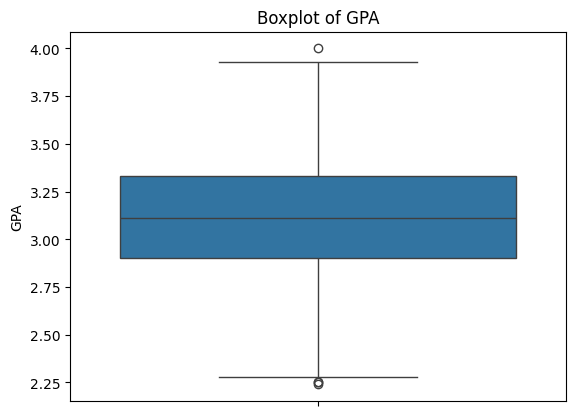

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Преобразование типа данных
df['Stress_Level'] = df['Stress_Level'].astype('category')

# Проверка на выбросы
sns.boxplot(df['GPA'])
plt.title('Boxplot of GPA')
plt.show()

# Нормализация данных
scaler = StandardScaler()
df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
      'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
      'Physical_Activity_Hours_Per_Day']] = scaler.fit_transform(
    df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
          'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
          'Physical_Activity_Hours_Per_Day']]
)

# Кодирование категориальных переменных
df = pd.get_dummies(df, columns=['Stress_Level'], drop_first=True)

# Удаление ненужного столбца
df.drop(columns=['Student_ID'], inplace=True)

In [ ]:
display(df.head())

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level_Low,Stress_Level_Moderate
0,-0.404487,1.566246,0.820734,0.056543,-1.005896,2.99,False,True
1,-1.528451,1.306633,0.341473,0.885882,-0.528470,2.75,True,False
2,-1.668947,1.652784,1.163063,-0.891273,0.108097,2.67,True,False
3,-0.685478,0.095105,-0.206253,-0.595080,0.864021,2.88,False,True
4,0.438487,-1.202961,-0.685514,-0.298888,0.903806,3.51,False,False


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns
from keras.layers import Dropout, BatchNormalization
from keras import regularizers

X = df.drop(columns=['PAG'])
y = df['GPA']  # Целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()
model.add(Dense(128, activation='elu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(64, activation='elu', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(32, activation='elu', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Обучение модели
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

predictions = model.predict(X_test)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 10.0891 - val_loss: 8.4424
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.8970 - val_loss: 6.4971
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.8690 - val_loss: 4.1132
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6635 - val_loss: 2.0464
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8045 - val_loss: 0.8263
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7737 - val_loss: 0.3488
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3866 - val_loss: 0.2224
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2773 - val_loss: 0.1867
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2483 - val_loss: 0.1838
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2489 - val_loss: 0.1833
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2449 - val_loss: 0.1814
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

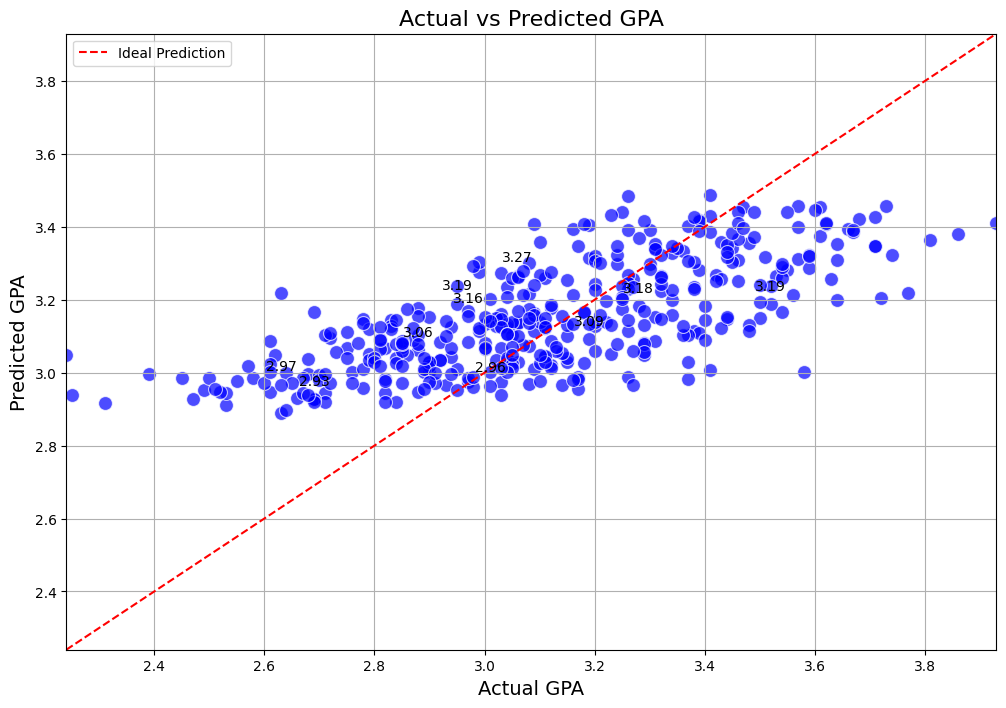

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Преобразуем predictions в одномерный массив
predictions_flat = predictions.ravel()

# Визуализация результатов
plt.figure(figsize=(12, 8))

# Создаем scatter plot с использованием seaborn для улучшенной визуализации
sns.scatterplot(x=y_test, y=predictions_flat, color='blue', alpha=0.7, edgecolor='w', s=100)

# Добавляем линию идеального предсказания
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Prediction')

# Добавляем аннотации для некоторых точек
for i in range(0, len(y_test), max(1, len(y_test) // 10)):  # аннотируем 10% точек
    plt.annotate(f'{predictions_flat[i]:.2f}', (y_test.iloc[i], predictions_flat[i]), textcoords="offset points", xytext=(0,10), ha='center')

# Настройка графика
plt.xlabel('Actual GPA', fontsize=14)
plt.ylabel('Predicted GPA', fontsize=14)
plt.title('Actual vs Predicted GPA', fontsize=16)
plt.legend()
plt.grid(True)

# Установка одинаковых масштабов для осей
plt.xlim(min(y_test), max(y_test))
plt.ylim(min(y_test), max(y_test))

plt.show()

In [ ]:
# Сохранение модели
model.save('gpa_prediction_model.h5')

# В Colab: Загрузка модели
from keras.models import load_model

loaded_model = load_model('gpa_prediction_model.h5')

In [ ]:
!pip install fastapi # Установим FastAPI
!pip install uvicorn # Установим ASGI-сервер
!pip install python-multipart # Необходимая зависимость для FastAPI (для работы с данными отправленных форм на сайте)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.3 MB/s eta 0:00:00


In [ ]:
%%writefile main.py
# импортируем FastAPI
from fastapi import FastAPI

# Создаем экземпляр класса FastAPI
app = FastAPI()


Overwriting main.py


In [ ]:
!nohup uvicorn main:app --reload &
# nohup и & - прописываются для запуска процесса в фоне (чтобы не блокировать Colab)
# параметр --reload позволяет автоматически перезапускать uvicorn при изменениях в файле main.py

nohup: appending output to 'nohup.out'


In [ ]:
!cat nohup.out

INFO:     Will watch for changes in these directories: ['/content']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [13470] using StatReload
ERROR:    Error loading ASGI app. Could not import module "main".
INFO:     Will watch for changes in these directories: ['/content']
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [13598] using StatReload
INFO:     Started server process [13600]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     127.0.0.1:48840 - "GET /test HTTP/1.1" 200 OK
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [13600]
INFO:     Started server process [13735]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    Traceback (most recent call last):
  File "/usr/lib/python3.11/as

In [ ]:
import requests
r = requests.get('http://127.0.0.1:8000/test')
print(r.status_code)
print(r.text)

200
{"Hello":"World"}


In [ ]:
!ssh -o "StrictHostKeyChecking no" -R 80:localhost:8000 serveo.net

Forwarding HTTP traffic from https://0034fca6c9431db939cb7cec2367be05.serveo.net
HTTP request from 109.233.236.24 to https://0034fca6c9431db939cb7cec2367be05.serveo.net/docs
HTTP request from 109.233.236.24 to https://0034fca6c9431db939cb7cec2367be05.serveo.net/openapi.json


In [ ]:
%%writefile main.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import numpy as np
from keras.models import load_model
from sklearn.preprocessing import StandardScaler
import json
import subprocess
import threading
import requests
from fastapi.middleware.cors import CORSMiddleware


In [ ]:
# Загрузка обученной модели
try:
    model = load_model('gpa_prediction_model.h5')
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

In [ ]:
app = FastAPI()

# Настройка CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


In [ ]:
# Определение класса для входных данных
class StudentData(BaseModel):
    Study_Hours_Per_Day: float
    Extracurricular_Hours_Per_Day: float
    Sleep_Hours_Per_Day: float
    Social_Hours_Per_Day: float
    Physical_Activity_Hours_Per_Day: float
    Stress_Level: str

In [ ]:
def preprocess_data(input_data: StudentData):
    try:
        data = {
            'Study_Hours_Per_Day': [input_data.Study_Hours_Per_Day],
            'Extracurricular_Hours_Per_Day': [input_data.Extracurricular_Hours_Per_Day],
            'Sleep_Hours_Per_Day': [input_data.Sleep_Hours_Per_Day],
            'Social_Hours_Per_Day': [input_data.Social_Hours_Per_Day],
            'Physical_Activity_Hours_Per_Day': [input_data.Physical_Activity_Hours_Per_Day],
            'Stress_Level': [input_data.Stress_Level]
        }

        df = pd.DataFrame(data)

        # One-hot encoding для Stress_Level
        df['Stress_Level_Low'] = df['Stress_Level'].apply(lambda x: 1 if x == 'Low' else 0)
        df['Stress_Level_Moderate'] = df['Stress_Level'].apply(lambda x: 1 if x == 'Moderate' else 0)
        df.drop('Stress_Level', axis=1, inplace=True)

        # Нормализация
        scaler = StandardScaler()
        numerical_cols = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
                         'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
                         'Physical_Activity_Hours_Per_Day']
        df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

        return df.values
    except Exception as e:
        raise ValueError(f"Data preprocessing error: {e}")

In [ ]:
@app.get("/")
def read_root():
    return {"message": "Student GPA Prediction API",
            "endpoints": {
                "/predict": "POST student data to get GPA prediction",
                "/test": "Simple test endpoint"
            }}

In [ ]:
@app.get("/test")
def test_endpoint():
    return {"status": "API is working", "model_loaded": model is not None}


In [ ]:
@app.post("/predict")
async def predict_gpa(student_data: StudentData):
    if not model:
        raise HTTPException(status_code=500, detail="Model not loaded")

    try:
        input_array = preprocess_data(student_data)
        prediction = model.predict(input_array)
        return {"predicted_gpa": float(prediction[0][0])}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

In [ ]:
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

if __name__ == "__main__":
    # Запуск сервера в отдельном потоке
    server_thread = threading.Thread(target=run_server)
    server_thread.daemon = True
    server_thread.start()

    import time
    time.sleep(3)


Overwriting main.py


In [ ]:
    !ssh -o StrictHostKeyChecking=no -R 80:localhost:8000 serveo.net

Forwarding HTTP traffic from https://814dce51c73a939b225d91e73a41a902.serveo.net
HTTP request from 109.233.236.24 to https://814dce51c73a939b225d91e73a41a902.serveo.net/docs
HTTP request from 109.233.236.24 to https://814dce51c73a939b225d91e73a41a902.serveo.net/openapi.json
HTTP request from 109.233.236.24 to https://814dce51c73a939b225d91e73a41a902.serveo.net/predict


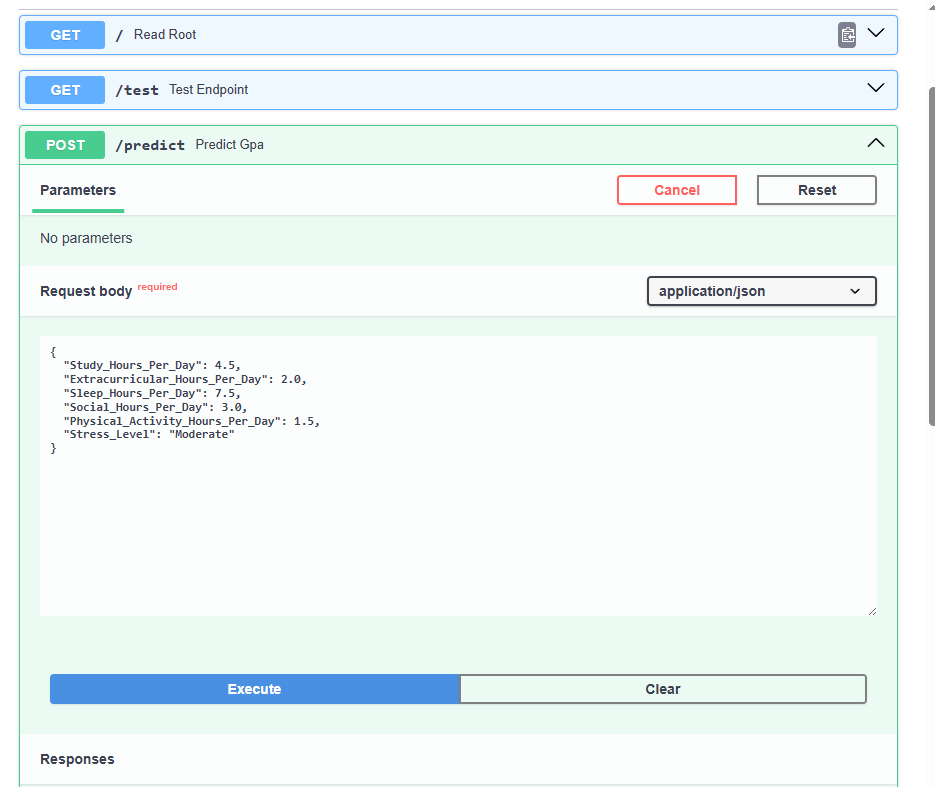

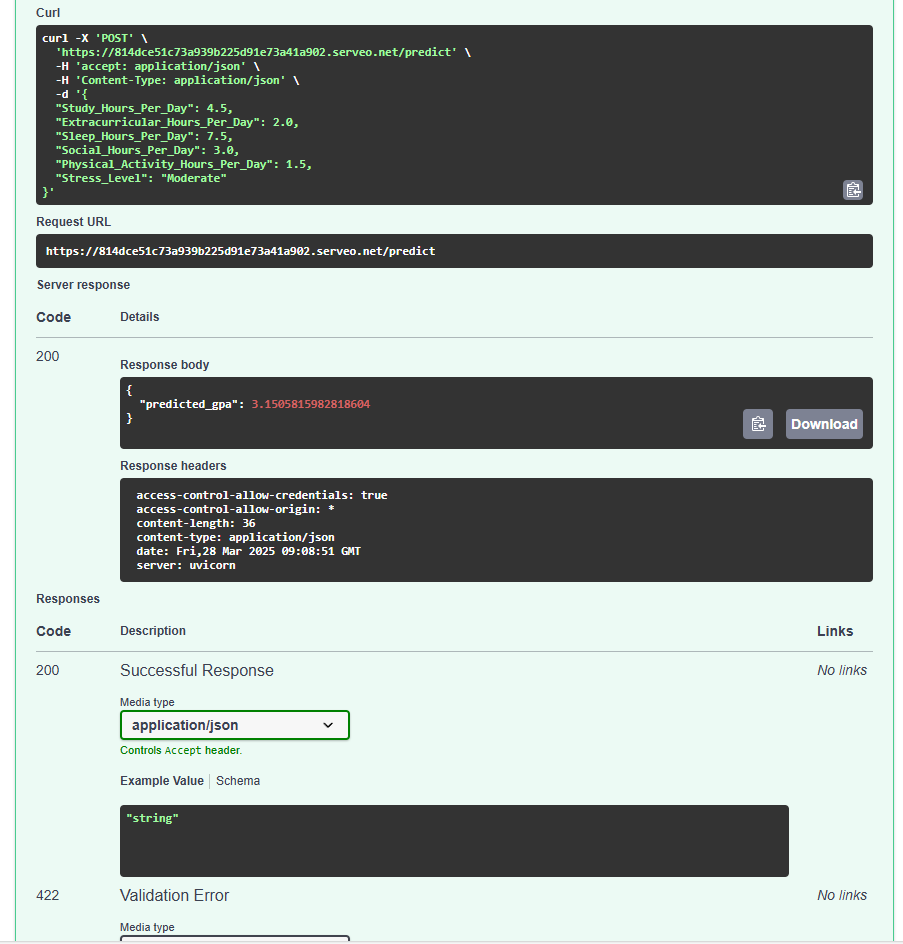

Заключение:

В рамках поставленной задачи был разработан REST API, обеспечивающий возможность взаимодействия с моделью нейронной сети, предназначенной для предсказания среднего балла (GPA) студентов. Этот API позволяет сторонним приложениям использовать возможности модели, не требуя знания деталей ее внутренней реализации.

Ключевыми этапами реализации стали:

Построение модели предсказания: Обучена многослойная нейронная сеть, учитывающая такие факторы, как учебные часы, внеучебная деятельность, режим сна, социальная активность и уровень стресса, для достижения адекватной точности предсказания GPA. Были применены методы регуляризации и нормализации для повышения устойчивости и обобщающей способности модели.

Обеспечение воспроизводимости: Для гарантии корректной работы API в реальных условиях, были сохранены не только веса обученной нейронной сети, но и объекты StandardScaler, используемые для масштабирования признаков, а также список столбцов X_train.columns, определяющий структуру входных данных. Это позволяет обеспечить идентичную предобработку данных как на этапе обучения, так и на этапе предсказания.

Создание REST API на базе FastAPI: Разработан API с использованием фреймворка FastAPI, предоставляющего современный и эффективный способ создания RESTful веб-сервисов. API предоставляет endpoint /predict, принимающий POST-запросы, содержащие данные о студенте. Внутри API осуществляется валидация входящих данных, их предобработка с использованием сохраненных объектов, выполнение предсказания с помощью обученной модели и формирование ответа в формате JSON.

Консистентность данных как приоритет: Особое внимание уделено обеспечению консистентности предобработки данных. Загрузка и применение сохраненных объектов StandardScaler и списка столбцов X_train.columns гарантирует, что входящие данные будут обработаны точно так же, как и данные, использованные при обучении модели, что минимизирует риск ошибок и повышает надежность предсказаний.

Развертывание и тестирование API: API успешно развернут в среде Google Colab и протестирован с использованием запросов, имитирующих реальные сценарии использования. Для обеспечения внешнего доступа к API использован сервис `serveo.net